In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# prepare the testing data
y_actual  = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0])
y_predicted = np.array([1, 0, 1, 0, 0, 1, 0, 1, 1, 0])

df = pd.DataFrame({'Actual': y_actual, 'Predicted': y_predicted})

accuracy = accuracy_score(y_actual, y_predicted)
precision = precision_score(y_actual, y_predicted)
recall = recall_score(y_actual, y_predicted)
f1 = f1_score(y_actual, y_predicted)

metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})
metrics


,Metric,Score
0,Accuracy,0.8
1,Precision,0.8
2,Recall,0.8
3,F1 Score,0.8


In [9]:
y_actual = np.random.choice([0, 1], size=1000)
y_predicted = np.random.choice([0, 1], size=1000)


[0.         0.52191235 1.        ] [0.         0.48795181 1.        ] [inf  1.  0.]


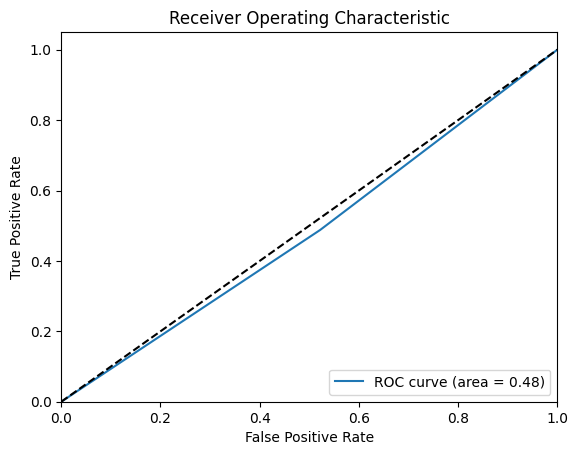

In [11]:
# roc and auc curve
from sklearn.metrics import roc_curve, auc
# y_actual  = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0])
# y_predicted = np.array([1, 0, 1, 0, 0, 1, 0, 1, 1, 0])
plt.figure()
fpr, tpr, thresholds = roc_curve(y_actual, y_predicted)
print(fpr, tpr, thresholds)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


In [13]:
# log loss 
# lets there are two model
Y_actual = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0])
Y_predicted_1 = np.array([0.9, 0.1, 0.8, 0.7, 0.2, 0.6, 0.4, 0.3, 0.9, 0.1]) # from model 1
Y_predicted_2 = np.array([0.6, 0.4, 0.5, 0.2, 0.1, 0.8, 0.7, 0.9, 0.3, 0.2]) # from model 2

log_loss_1 = -np.mean(Y_actual * np.log(Y_predicted_1) + (1 - Y_actual) * np.log(1 - Y_predicted_1))
log_loss_2 = -np.mean(Y_actual * np.log(Y_predicted_2) + (1 - Y_actual) * np.log(1 - Y_predicted_2))
print(f'Log Loss Model 1: {log_loss_1}')
print(f'Log Loss Model 2: {log_loss_2}')

# when to use log loss?
# 1: When you want to evaluate the performance of a classification model that outputs probabilities.
# 2: When you want to penalize false classifications more heavily.
# 3 : When you want to compare different models based on their predicted probabilities. Champion vs Challenger

Log Loss Model 1: 0.2602730300669171
Log Loss Model 2: 0.8586414660458189


In [21]:
# regression one
# MAE : mean absolute error
y_actual = np.array([220, 180, 250, 300, 150])
y_predicted = np.array([200, 190, 240, 310, 160])
mae = np.mean(np.abs(y_actual - y_predicted))
print(f'Mean Absolute Error: {mae}')

# mae = 12. ?
# indicates that predicted values are, on average, 12 units away from the actual values.

# MSE : mean squared error
mse = np.mean((y_actual - y_predicted) ** 2)
print(f'Mean Squared Error: {mse}')

# mse = 160. ?
# indicates that predicted values are, on average, 160 squared units away from the actual values.
# you can bring back to the original scale by taking the square root of the MSE.
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error: {rmse}')

# rmse = 12.65 ?
# indicates that predicted values are, on average, 12.65 units away from the actual values.

# rmse and mae seems to be in the same range, indicating similar levels of error.

# r2 : R-squared
ss_total = np.sum((y_actual - np.mean(y_actual)) ** 2)
ss_residual = np.sum((y_actual - y_predicted) ** 2)
r2 = 1 - (ss_residual / ss_total)
print(f'R-squared: {r2}')

# R-squared = 0.94 ?
# indicates that 94% of the variance in the actual values is explained by the model.


Mean Absolute Error: 12.0
Mean Squared Error: 160.0
Root Mean Squared Error: 12.649110640673518
R-squared: 0.9420289855072463
